# Support Vector Regression (PyTorch)

AQI prediction using a shallow MLP as a PyTorch replacement for SVR.
2 hidden layers with BatchNorm approximate non-linear SVR behavior.
Trained independently per city with robust data-driven preprocessing.

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [2]:
# Load the multi-city AQI dataset
df = pd.read_csv('city_day_AQI_pred_dataset.csv')
print(f"Raw dataset: {df.shape[0]} rows, {df.shape[1]} columns")

# Drop rows where AQI (target) is null
df = df.dropna(subset=['AQI'])
print(f"Rows with valid AQI: {len(df)}")

# Drop AQI_Bucket (categorical, derived from AQI)
df = df.drop(columns=['AQI_Bucket'])

df['Date'] = pd.to_datetime(df['Date'])

# All candidate pollutant feature columns
ALL_FEATURE_COLS = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3',
                    'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']

# City filter: need enough samples for reliable training
MIN_SAMPLES = 300
city_counts = df['City'].value_counts()
valid_cities = city_counts[city_counts >= MIN_SAMPLES].index.tolist()
df = df[df['City'].isin(valid_cities)]

print(f"\nValid cities ({len(valid_cities)}):")
for city in sorted(valid_cities):
    cdf = df[df['City'] == city]
    n = len(cdf)
    miss_pct = cdf[ALL_FEATURE_COLS].isna().mean() * 100
    bad_feats = miss_pct[miss_pct > 50].index.tolist()
    bad_str = f"  (will drop: {', '.join(bad_feats)})" if bad_feats else ""
    print(f"  {city:.<25} {n:>5} samples{bad_str}")

Raw dataset: 29531 rows, 16 columns
Rows with valid AQI: 24850

Valid cities (20):
  Ahmedabad................  1334 samples  (will drop: PM10, NH3)
  Amaravati................   841 samples
  Amritsar.................  1126 samples
  Bengaluru................  1910 samples  (will drop: Xylene)
  Brajrajnagar.............   713 samples  (will drop: Toluene, Xylene)
  Chennai..................  1884 samples  (will drop: PM10, Xylene)
  Coimbatore...............   344 samples  (will drop: Xylene)
  Delhi....................  1999 samples
  Gurugram.................  1453 samples  (will drop: NH3, Xylene)
  Guwahati.................   495 samples  (will drop: Toluene, Xylene)
  Hyderabad................  1880 samples
  Jaipur...................  1094 samples  (will drop: Xylene)
  Jorapokhar...............   771 samples  (will drop: PM2.5, NOx, Benzene, Toluene, Xylene)
  Kolkata..................   754 samples
  Lucknow..................  1893 samples  (will drop: PM10, Xylene)
  Mumbai.

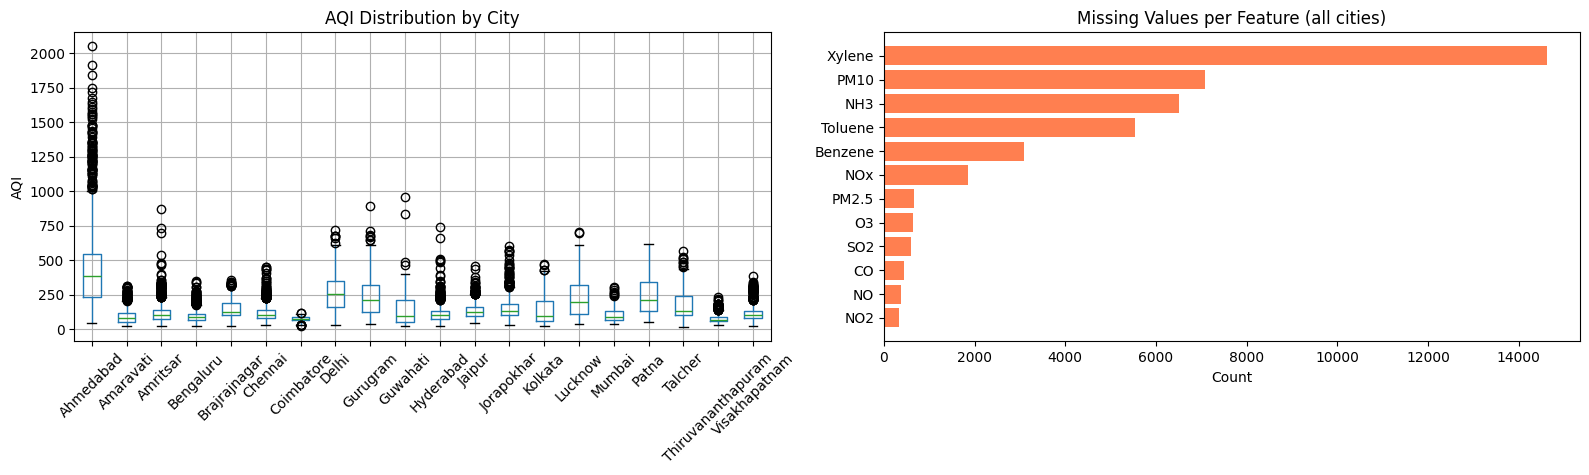

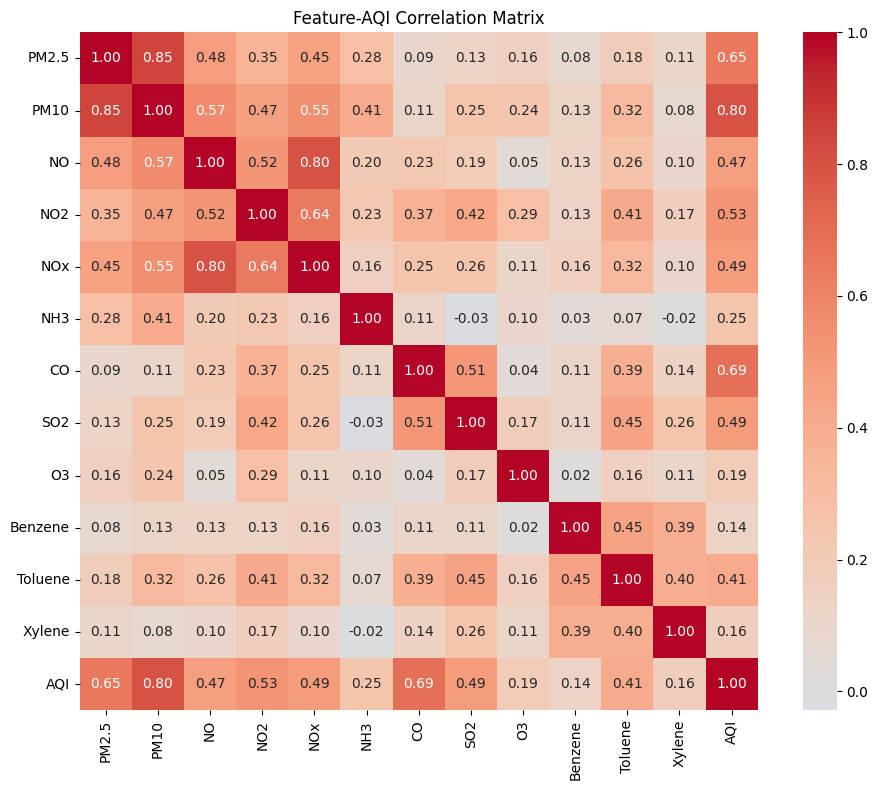

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
df.boxplot(column='AQI', by='City', ax=axes[0], rot=45)
axes[0].set_title('AQI Distribution by City')
axes[0].set_xlabel(''); axes[0].set_ylabel('AQI')
axes[0].get_figure().suptitle('')
miss = df[ALL_FEATURE_COLS].isna().sum().sort_values(ascending=True)
axes[1].barh(miss.index, miss.values, color='coral')
axes[1].set_title('Missing Values per Feature (all cities)')
axes[1].set_xlabel('Count')
plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 8))
corr = df[ALL_FEATURE_COLS + ['AQI']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Feature-AQI Correlation Matrix')
plt.tight_layout(); plt.show()

In [4]:
MISSING_THRESHOLD = 0.5
MIN_FEATURES = 3
VARIANCE_THRESHOLD = 0.01

def preprocess_city_data(df, city, all_feature_cols, test_ratio=0.2):
    '''Robust per-city preprocessing: filters bad features, removes outliers, scales.'''
    city_df = df[df['City'] == city].copy()
    city_df = city_df.sort_values('Date').reset_index(drop=True)

    # 1. Per-city feature quality filter: drop features >50% missing for THIS city
    missing_pct = city_df[all_feature_cols].isna().mean()
    usable_features = missing_pct[missing_pct < MISSING_THRESHOLD].index.tolist()
    dropped = sorted(set(all_feature_cols) - set(usable_features))
    if dropped:
        print(f"  Dropped {len(dropped)} sparse features: {dropped}")
    if len(usable_features) < MIN_FEATURES:
        print(f"  [SKIP] {city}: only {len(usable_features)} usable features")
        return None

    # 2. Interpolate remaining missing values
    city_df[usable_features] = city_df[usable_features].interpolate(
        method='linear', limit_direction='both'
    )
    for col in usable_features:
        if city_df[col].isna().any():
            city_df[col] = city_df[col].fillna(city_df[col].median())
    city_df = city_df.dropna(subset=usable_features + ['AQI'])

    # 3. IQR outlier removal
    Q1 = city_df['AQI'].quantile(0.25)
    Q3 = city_df['AQI'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    n_before = len(city_df)
    city_df = city_df[(city_df['AQI'] >= lower_bound) & (city_df['AQI'] <= upper_bound)]
    n_outliers = n_before - len(city_df)
    if n_outliers > 0:
        print(f"  Removed {n_outliers} AQI outliers (IQR: {lower_bound:.0f}-{upper_bound:.0f})")

    # 4. Drop near-zero variance features
    variances = city_df[usable_features].var()
    low_var = variances[variances < VARIANCE_THRESHOLD].index.tolist()
    if low_var:
        usable_features = [f for f in usable_features if f not in low_var]
        print(f"  Dropped {len(low_var)} low-variance features: {low_var}")

    if len(usable_features) < MIN_FEATURES or len(city_df) < 50:
        print(f"  [SKIP] {city}: insufficient data after cleaning")
        return None

    X = city_df[usable_features].values.astype(np.float32)
    y = city_df['AQI'].values.astype(np.float32)

    split = int((1 - test_ratio) * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    sc_x = StandardScaler()
    sc_y = StandardScaler()
    X_train_s = sc_x.fit_transform(X_train).astype(np.float32)
    X_test_s = sc_x.transform(X_test).astype(np.float32)
    y_train_s = sc_y.fit_transform(y_train.reshape(-1, 1)).flatten().astype(np.float32)
    y_test_s = sc_y.transform(y_test.reshape(-1, 1)).flatten().astype(np.float32)

    print(f"  Features used ({len(usable_features)}): {usable_features}")
    print(f"  Train: {len(X_train)} | Test: {len(X_test)}")

    return {
        'X_train': X_train_s, 'X_test': X_test_s,
        'y_train': y_train_s, 'y_test': y_test_s,
        'y_test_orig': y_test,
        'sc_x': sc_x, 'sc_y': sc_y,
        'n_train': len(X_train), 'n_test': len(X_test),
        'n_features': len(usable_features),
        'features': usable_features
    }

In [5]:
class SVRNet(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Linear(64, 32), nn.BatchNorm1d(32), nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

In [6]:
def train_model(model, X_train, y_train, X_val, y_val,
                num_epochs=500, lr=0.001, batch_size=32,
                patience=30, weight_decay=1e-4):
    '''Train with early stopping, LR scheduling, and gradient clipping.'''
    model = model.to(device)
    train_ds = TensorDataset(
        torch.FloatTensor(X_train).to(device),
        torch.FloatTensor(y_train).to(device)
    )
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6
    )

    X_val_t = torch.FloatTensor(X_val).to(device)
    y_val_t = torch.FloatTensor(y_val).to(device)

    best_val_loss = float('inf')
    best_state = None
    no_improve = 0
    history = {'train': [], 'val': []}

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            out = model(xb).squeeze(-1)
            loss = criterion(out, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()

        avg_train = epoch_loss / len(train_loader)
        history['train'].append(avg_train)

        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t).squeeze(-1)
            val_loss = criterion(val_pred, y_val_t).item()
        history['val'].append(val_loss)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience and epoch > 50:
            break

    if best_state:
        model.load_state_dict(best_state)
    return model, history

In [7]:
def evaluate_model(model, X_test, y_test_orig, sc_y):
    model.eval()
    with torch.no_grad():
        preds_s = model(torch.FloatTensor(X_test).to(device)).squeeze(-1).cpu().numpy()
    preds = sc_y.inverse_transform(preds_s.reshape(-1, 1)).flatten()
    actuals = y_test_orig
    return {
        'predictions': preds, 'actuals': actuals,
        'r2': r2_score(actuals, preds),
        'mse': mean_squared_error(actuals, preds),
        'rmse': np.sqrt(mean_squared_error(actuals, preds)),
        'mae': mean_absolute_error(actuals, preds),
        'mape': np.mean(np.abs((actuals - preds) / np.where(actuals == 0, 1, actuals))) * 100
    }

In [8]:
def plot_results(all_results, model_name):
    n = len(all_results)
    fig, axes = plt.subplots(n, 1, figsize=(14, 4 * n))
    if n == 1: axes = [axes]
    for ax, (city, res) in zip(axes, all_results.items()):
        ax.plot(res['actuals'], label='Actual AQI', color='steelblue', alpha=0.8, lw=1.2)
        ax.plot(res['predictions'], label='Predicted AQI', color='tomato', alpha=0.8, lw=1.2)
        ax.set_title(f'{city}  |  R² = {res["r2"]:.4f}  |  RMSE = {res["rmse"]:.2f}  |  MAE = {res["mae"]:.2f}',
                     fontsize=11, fontweight='bold')
        ax.set_xlabel('Test Sample'); ax.set_ylabel('AQI')
        ax.legend(loc='upper right'); ax.grid(True, alpha=0.3)
    plt.suptitle(f'{model_name} — Per-City AQI Predictions', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.show()

def plot_training_curves(all_histories, model_name):
    n = len(all_histories)
    cols = min(3, n); rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = np.array(axes).flatten() if n > 1 else [axes]
    for ax, (city, hist) in zip(axes, all_histories.items()):
        ax.plot(hist['train'], label='Train', alpha=0.8)
        ax.plot(hist['val'], label='Val', alpha=0.8)
        ax.set_title(city, fontsize=10); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    for ax in axes[n:]: ax.set_visible(False)
    plt.suptitle(f'{model_name} — Training Curves', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

In [9]:
all_results = {}
all_histories = {}

for city in sorted(valid_cities):
    print(f"\n{'='*60}")
    print(f"  SVR (Shallow MLP) — {city}")
    print(f"{'='*60}")

    data = preprocess_city_data(df, city, ALL_FEATURE_COLS)
    if data is None:
        continue

    input_size = data['n_features']
    model = SVRNet(input_size)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"  Model parameters: {n_params:,}")

    model, history = train_model(
        model, data['X_train'], data['y_train'],
        data['X_test'], data['y_test'],
        num_epochs=500, lr=0.001, batch_size=32,
        patience=30, weight_decay=0.0001
    )

    results = evaluate_model(model, data['X_test'], data['y_test_orig'], data['sc_y'])
    results['n_train'] = data['n_train']
    results['n_test'] = data['n_test']
    results['n_features'] = data['n_features']
    all_results[city] = results
    all_histories[city] = history

    print(f"  >> R²={results['r2']:.4f} | RMSE={results['rmse']:.2f} | MAE={results['mae']:.2f}")

print(f"\nDone! Trained on {len(all_results)} cities.")


  SVR (Shallow MLP) — Ahmedabad
  Dropped 2 sparse features: ['NH3', 'PM10']
  Removed 92 AQI outliers (IQR: -237-1010)
  Features used (10): ['PM2.5', 'NO', 'NO2', 'NOx', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']
  Train: 993 | Test: 249
  Model parameters: 3,009
  >> R²=0.7419 | RMSE=99.97 | MAE=73.31

  SVR (Shallow MLP) — Amaravati
  Removed 52 AQI outliers (IQR: -35-205)
  Features used (12): ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']
  Train: 631 | Test: 158
  Model parameters: 3,137
  >> R²=-0.5502 | RMSE=20.74 | MAE=14.96

  SVR (Shallow MLP) — Amritsar
  Removed 95 AQI outliers (IQR: -23-232)
  Features used (12): ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']
  Train: 824 | Test: 207
  Model parameters: 3,137
  >> R²=0.6176 | RMSE=23.81 | MAE=15.79

  SVR (Shallow MLP) — Bengaluru
  Dropped 1 sparse features: ['Xylene']
  Removed 71 AQI outliers (IQR: 1-177)
  Featu

In [10]:
print("\n" + "=" * 90)
print(f"  PERFORMANCE SUMMARY")
print("=" * 90)
print(f"  {'City':<20} {'R²':>8} {'RMSE':>10} {'MAE':>10} {'MSE':>12} {'Features':>10} {'Split':>12} {'Accuracy%':>10}")
print("-" * 90)
for city in sorted(all_results.keys()):
    r = all_results[city]
    nf = r.get('n_features', '?')
    flag = " ⚠" if r['r2'] < 0.5 else ""
    print(f"  {city:<20} {r['r2']:>8.4f} {r['rmse']:>10.2f} {r['mae']:>10.2f} {r['mse']:>12.2f} {nf:>10} {r['n_train']}+{r['n_test']}  {max(0, 100 - r.get('mape', 0)):>8.1f}%{flag}")
print("-" * 90)
avg_r2 = np.mean([r['r2'] for r in all_results.values()])
avg_rmse = np.mean([r['rmse'] for r in all_results.values()])
avg_mae = np.mean([r['mae'] for r in all_results.values()])
avg_acc = np.mean([max(0, 100 - r.get('mape', 0)) for r in all_results.values()])
print(f"  {'AVERAGE':<20} {avg_r2:>8.4f} {avg_rmse:>10.2f} {avg_mae:>10.2f}{"":>12} {"":>10} {avg_acc:>8.1f}%")
print("=" * 90)
if any(r['r2'] < 0.5 for r in all_results.values()):
    print("  ⚠ = R² < 0.5 (weak model — likely due to data quality or distribution shift)")


  PERFORMANCE SUMMARY
  City                       R²       RMSE        MAE          MSE   Features        Split  Accuracy%
------------------------------------------------------------------------------------------
  Ahmedabad              0.7419      99.97      73.31      9994.83         10 993+249      62.1%
  Amaravati             -0.5502      20.74      14.96       429.99         12 631+158      69.0% ⚠
  Amritsar               0.6176      23.81      15.79       566.88         12 824+207      83.3%
  Bengaluru              0.8245       8.32       6.38        69.25         11 1471+368      91.5%
  Brajrajnagar          -2.0739      88.13      57.68      7766.48         10 556+139      47.7% ⚠
  Chennai                0.4503      19.02      15.30       361.73         10 1452+364      80.6% ⚠
  Coimbatore             0.4119      15.63      13.95       244.20          9 268+68      69.3% ⚠
  Delhi                  0.9429      26.63      20.15       709.29         12 1594+399      88.0

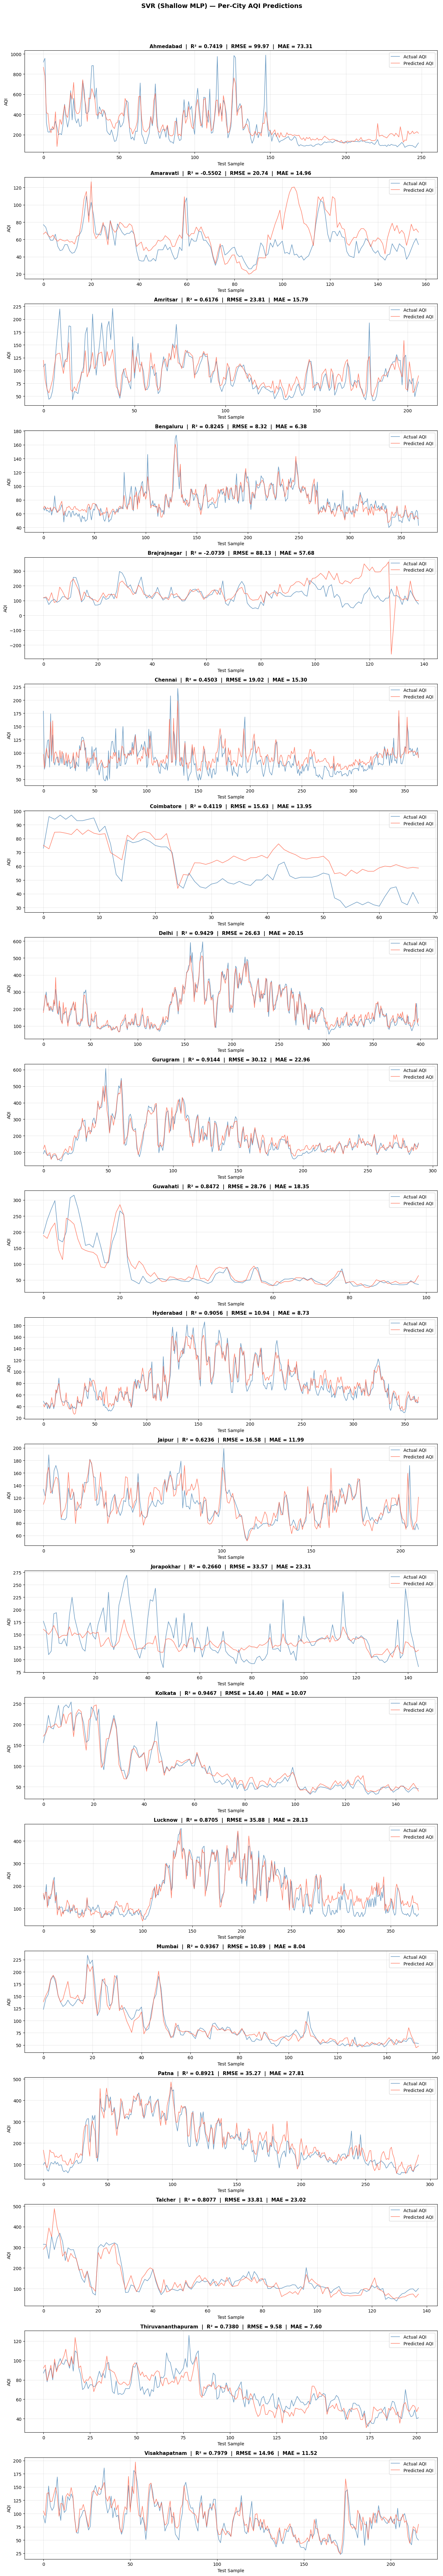

In [11]:
plot_results(all_results, 'SVR (Shallow MLP)')

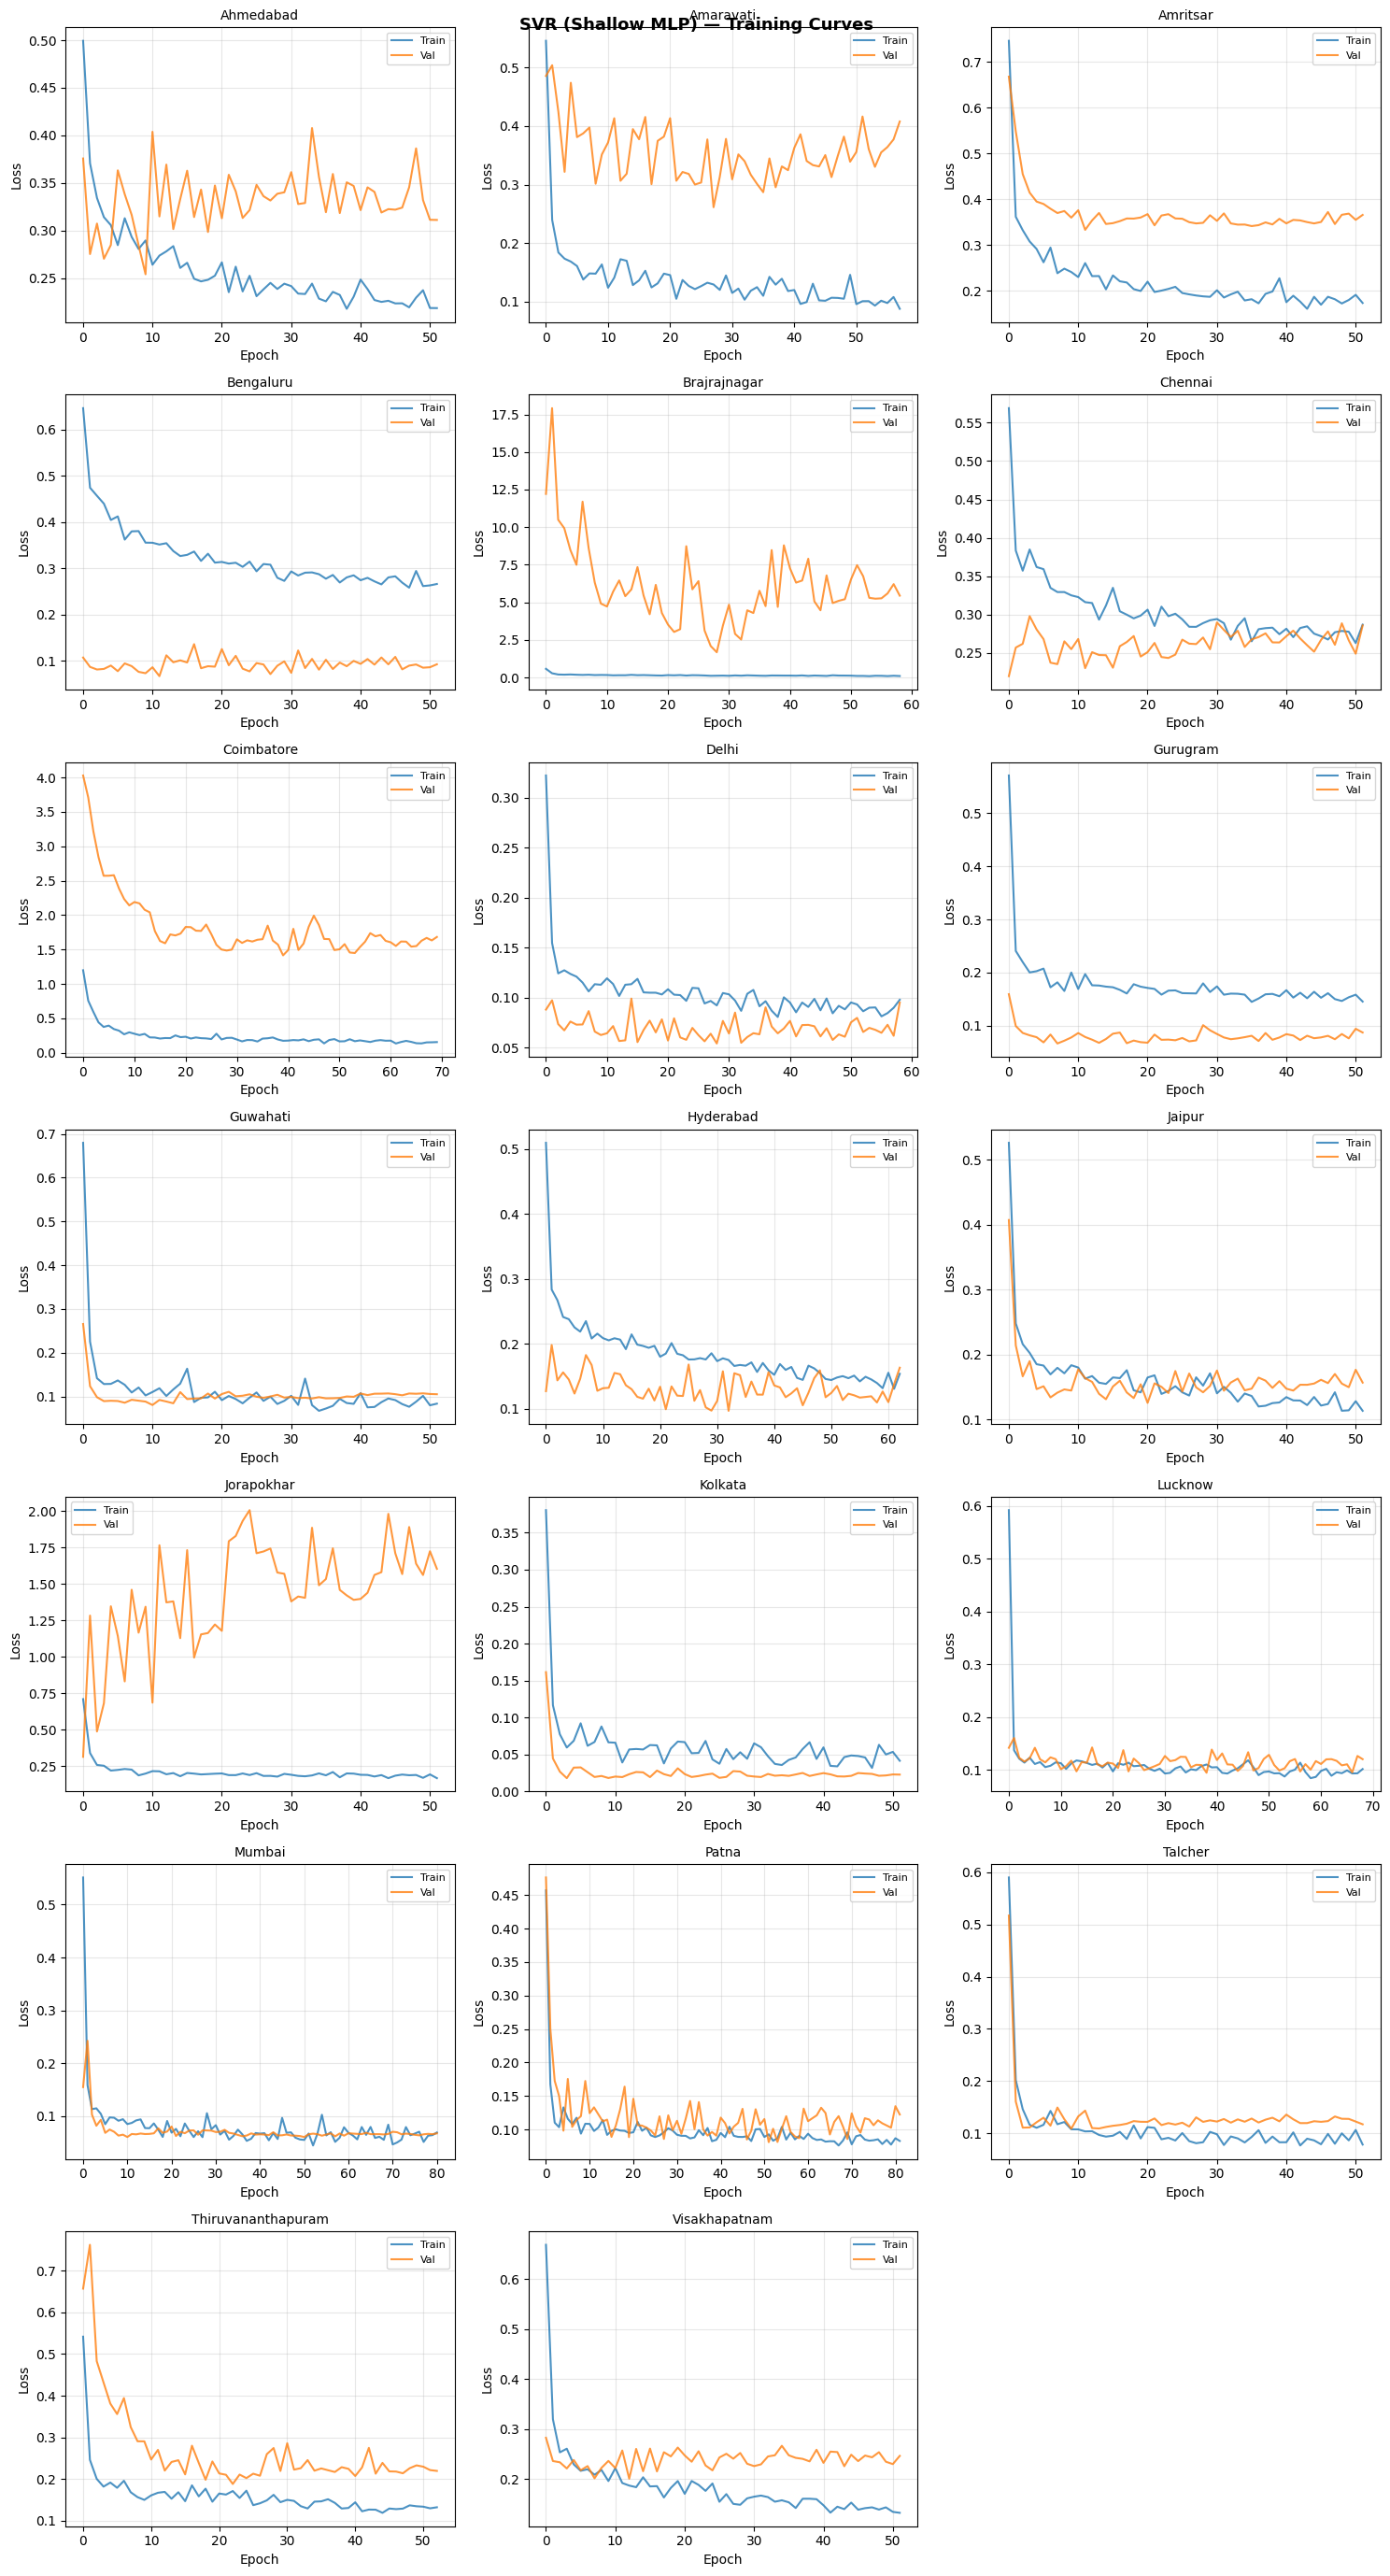

In [12]:
plot_training_curves(all_histories, 'SVR (Shallow MLP)')